**Task:** Binary classification — predict `PitNextLap`

In [25]:
# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and validation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# The three supplied supervised algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

RANDOM_STATE = 42

In [26]:
df = pd.read_csv("f1.csv")

## 1. Exploratory Data Analysis

In [27]:
df.shape

(101371, 17)

In [28]:
df.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change,Prev_TyreLife
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0.0,0.017241,0.117647,0.0,NaN
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0.0,0.034483,0.176471,-1.0,2.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0.0,0.051724,0.235294,0.0,3.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0.0,0.068966,0.294118,0.0,4.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0.0,0.086207,0.352941,0.0,5.0


In [29]:
df.dtypes

Driver                        str
LapNumber                   int64
Compound                      str
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
Race                          str
Year                        int64
LapTime_Delta             float64
Cumulative_Degradation    float64
PitStop                     int64
PitNextLap                float64
RaceProgress              float64
Normalized_TyreLife       float64
Position_Change           float64
Prev_TyreLife             float64
dtype: object

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df.isna().sum()

Driver                       0
LapNumber                    0
Compound                    66
Stint                        0
TyreLife                     0
Position                     0
LapTime (s)                  0
Race                         0
Year                         0
LapTime_Delta                0
Cumulative_Degradation       0
PitStop                      0
PitNextLap                   1
RaceProgress                 0
Normalized_TyreLife          0
Position_Change              0
Prev_TyreLife             1848
dtype: int64

C:\Users\AM BUSINESS 99\AppData\Local\Temp\ipykernel_12100\95508925.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="PitNextLap", palette="viridis", ax=axes[0])


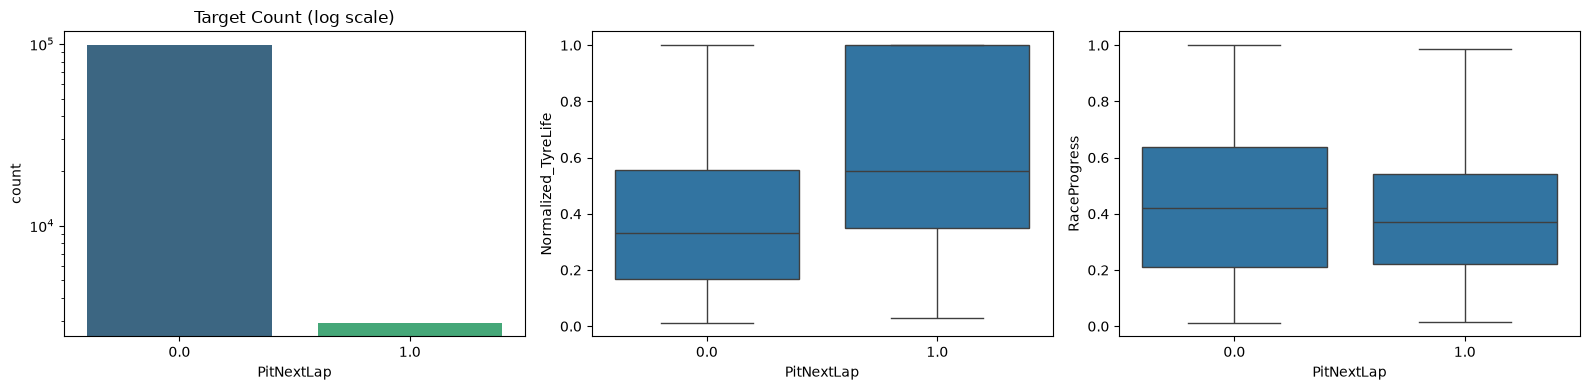

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=df, x="PitNextLap", palette="viridis", ax=axes[0])
axes[0].set_yscale("log"); axes[0].set_title("Target Count (log scale)")
sns.boxplot(data=df, x="PitNextLap", y="Normalized_TyreLife", ax=axes[1])
sns.boxplot(data=df, x="PitNextLap", y="RaceProgress", ax=axes[2])
plt.tight_layout(); plt.show()

## 2. Train-Test Split Before Preprocessing

In [33]:
model_df = df.dropna(subset=["PitNextLap"]).copy()
X = model_df.drop(columns=["PitNextLap"])
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(model_df["PitNextLap"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

## 3. Missing Values, One-Hot Encoding and Standardization

In [34]:
def fit_preprocessing(X_train, X_test):
    numeric_columns = X_train.select_dtypes(include=np.number).columns.tolist()
    categorical_columns = X_train.select_dtypes(exclude=np.number).columns.tolist()

    # Numeric missing values: training medians only.
    train_medians = X_train[numeric_columns].median()
    X_train_num = X_train[numeric_columns].fillna(train_medians)
    X_test_num = X_test[numeric_columns].fillna(train_medians)

    # Nominal categories: training modes followed by supplied OneHotEncoder.
    if categorical_columns:
        train_modes = X_train[categorical_columns].mode().iloc[0]
        X_train_cat = X_train[categorical_columns].fillna(train_modes)
        X_test_cat = X_test[categorical_columns].fillna(train_modes)
        onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        X_train_cat_encoded = onehot_encoder.fit_transform(X_train_cat)
        X_test_cat_encoded = onehot_encoder.transform(X_test_cat)


    
    scaler = StandardScaler()
    X_train_num_scaled = scaler.fit_transform(X_train_num)
    X_test_num_scaled = scaler.transform(X_test_num)

    X_train_processed = np.hstack([X_train_num_scaled, X_train_cat_encoded])
    X_test_processed = np.hstack([X_test_num_scaled, X_test_cat_encoded])

    print("Numeric columns:", len(numeric_columns))
    print("Categorical columns:", categorical_columns)
    print("Processed train shape:", X_train_processed.shape)
    print("Processed test shape:", X_test_processed.shape)
    return X_train_processed, X_test_processed, scaler, onehot_encoder

X_train_scaled, X_test_scaled, scaler, onehot_encoder = fit_preprocessing(X_train, X_test)

Numeric columns: 13
Categorical columns: ['Driver', 'Compound', 'Race']
Processed train shape: (81096, 77)
Processed test shape: (20274, 77)


## 4. Cross Validation, Regularization, Tuning and Three Models

In [35]:
# Stratified CV from the supplied workflow.
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

baseline_model = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
baseline_scores = cross_val_score(
    baseline_model, X_train_scaled, y_train,
    cv=cv_strategy, scoring="f1"
)
print("Baseline Logistic Regression fold F1 scores:", np.round(baseline_scores, 4))
print("Mean CV F1:", round(baseline_scores.mean(), 4),
      "| Standard deviation:", round(baseline_scores.std(), 4))

Baseline Logistic Regression fold F1 scores: [0.0276 0.0447 0.0251]
Mean CV F1: 0.0325 | Standard deviation: 0.0087


In [36]:
regularization_results = []
for penalty in ["l1", "l2"]:
    model = LogisticRegression(
        penalty=penalty, solver="liblinear", C=1.0,
        max_iter=10000, random_state=RANDOM_STATE
    )
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=cv_strategy, scoring="f1")
    regularization_results.append({
        "Penalty": penalty.upper(),
        "Mean CV F1": scores.mean(),
        "CV F1 Std": scores.std()
    })
print(pd.DataFrame(regularization_results).round(4))

c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use

  Penalty  Mean CV F1  CV F1 Std
0      L1      0.0316     0.0093
1      L2      0.0325     0.0087


In [37]:
param_grid = {
    "C": [0.1, 1],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}
grid_search = GridSearchCV(
    LogisticRegression(max_iter=10000, random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="f1"
)
grid_search.fit(X_train_scaled, y_train)
print("Best Logistic Regression parameters:", grid_search.best_params_)
print("Best Logistic Regression CV F1:", round(grid_search.best_score_, 4))

c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use

Best Logistic Regression parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Logistic Regression CV F1: 0.0325


In [38]:
SVM_TRAIN_LIMIT = 10000
if len(X_train_scaled) > SVM_TRAIN_LIMIT:
    X_svm_train, _, y_svm_train, _ = train_test_split(
        X_train_scaled, y_train, train_size=SVM_TRAIN_LIMIT,
        random_state=RANDOM_STATE, stratify=y_train
    )

In [24]:
svm_param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.1],
    "kernel": ["rbf"]
}
svm_search = GridSearchCV(
    SVC(class_weight="balanced", random_state=RANDOM_STATE),
    param_grid=svm_param_grid,
    cv=cv_strategy,
    scoring="f1"
)
svm_search.fit(X_svm_train, y_svm_train)
print("Best Balanced-SVM parameters:", svm_search.best_params_)
print("Best Balanced-SVM CV F1:", round(svm_search.best_score_, 4))

balanced_svm = SVC(
    **svm_search.best_params_,
    class_weight="balanced",
    probability=True,
    random_state=RANDOM_STATE
)

Best Balanced-SVM parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Balanced-SVM CV F1: 0.3201


In [39]:
models = {
    "Logistic Regression": grid_search.best_estimator_,
    "Random Forest": RandomForestClassifier(
        n_estimators=200, min_samples_leaf=10, random_state=RANDOM_STATE
    ),
    "SVM (RBF Kernel)": SVC(
        kernel="rbf", probability=True, random_state=RANDOM_STATE
    )
}

trained_models = {}
train_f1 = {}
for name, model in models.items():
    if name == "SVM (RBF Kernel)":
        model.fit(X_svm_train, y_svm_train)
        train_prediction = model.predict(X_svm_train)
        train_f1[name] = f1_score(y_svm_train, train_prediction, zero_division=0)
    else:
        model.fit(X_train_scaled, y_train)
        train_prediction = model.predict(X_train_scaled)
        train_f1[name] = f1_score(y_train, train_prediction, zero_division=0)
    trained_models[name] = model
    print(name, "trained successfully.")

c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Logistic Regression trained successfully.
Random Forest trained successfully.


c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM (RBF Kernel) trained successfully.


## 5. Model Evaluation

In [40]:
evaluation_rows = []
predictions = {}
probabilities = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_proba
    test_f1 = f1_score(y_test, y_pred, zero_division=0)
    evaluation_rows.append({
        "Model": name,
        "Train F1": train_f1[name],
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred, zero_division=0),
        "Test F1": test_f1,
        "Test ROC-AUC": roc_auc_score(y_test, y_proba),
        "Train-Test F1 Gap": train_f1[name] - test_f1
    })

evaluation_df = pd.DataFrame(evaluation_rows).set_index("Model").sort_values("Test F1", ascending=False)
print(evaluation_df.round(4))

                     Train F1  Test Accuracy  Test Precision  Test Recall  \
Model                                                                       
Random Forest          0.4247         0.9786          0.9871       0.2620   
Logistic Regression    0.0309         0.9714          0.6250       0.0171   
SVM (RBF Kernel)       0.0000         0.9712          0.0000       0.0000   

                     Test F1  Test ROC-AUC  Train-Test F1 Gap  
Model                                                          
Random Forest         0.4141        0.9712             0.0107  
Logistic Regression   0.0333        0.8234            -0.0024  
SVM (RBF Kernel)      0.0000        0.8985             0.0000  


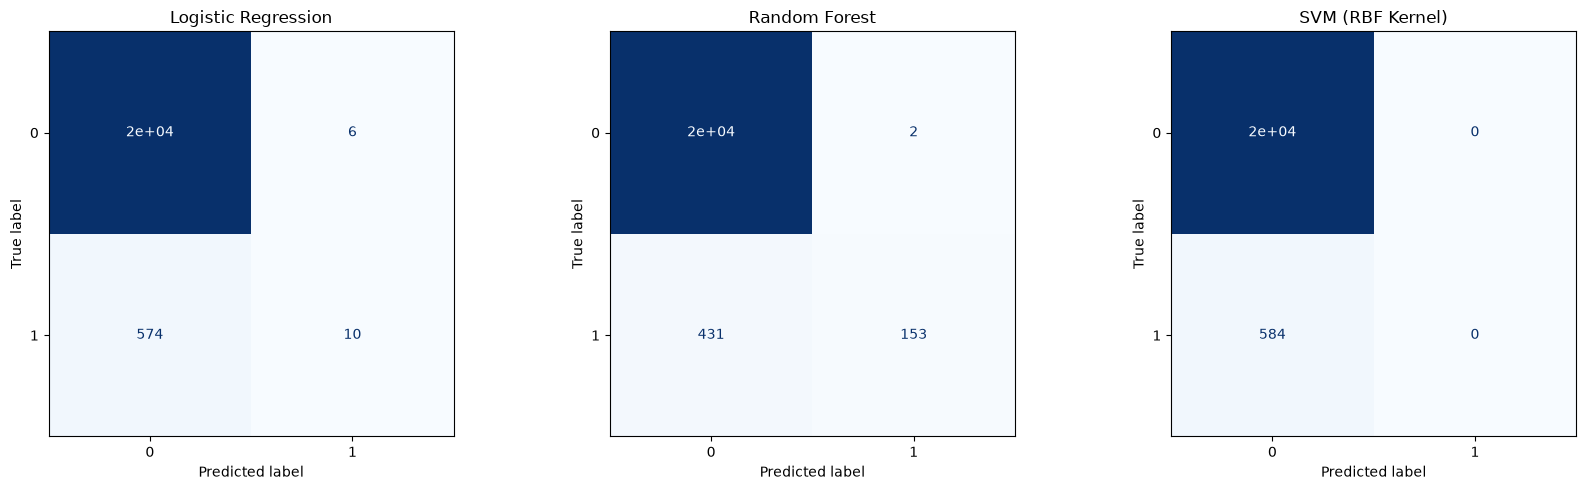

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (name, model) in zip(axes, trained_models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions[name], ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

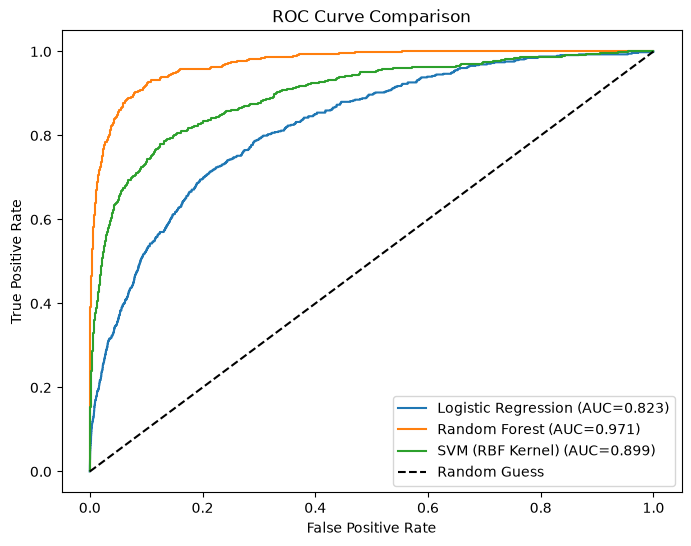

In [42]:
plt.figure(figsize=(8, 6))
for name in trained_models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_value = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## 6. Final Model and Overfit/Underfit Check

In [43]:
best_model_name = evaluation_df["Test F1"].idxmax()
print("Best model by Test F1:", best_model_name)
print("\nClassification Report:\n")
print(classification_report(y_test, predictions[best_model_name]))

Best model by Test F1: Random Forest

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     19690
           1       0.99      0.26      0.41       584

    accuracy                           0.98     20274
   macro avg       0.98      0.63      0.70     20274
weighted avg       0.98      0.98      0.97     20274



In [44]:
best_row = evaluation_df.loc[best_model_name]
print("Final selected model:", best_model_name)
print(best_row.round(4).to_string())

Final selected model: Random Forest
Train F1             0.4247
Test Accuracy        0.9786
Test Precision       0.9871
Test Recall          0.2620
Test F1              0.4141
Test ROC-AUC         0.9712
Train-Test F1 Gap    0.0107
